# Optimizing Von Mises Stress in Stellarator Coils

End-to-end tutorial from coil DOFs to gradient-based structural optimisation
using **coilforce** + **JAX-FEM**.

## Contents

1. [Setup & imports](#1-setup)
2. [Define base coils (fill in your data)](#2-coils)
3. [Build the CoilFEM container](#3-coilfem)
4. [Diagnostic forward solve & visualisation](#4-run)
5. [Verify gradients with a finite-difference check](#5-grad-check)
6. [JAX-native L-BFGS-B optimisation](#6-jax-optim)
7. [Scipy L-BFGS-B with simsopt objectives](#7-scipy-optim)
8. [Post-processing](#8-postproc)

---
> **Prerequisites**: install coilforce with the `[fem]` extra:  
> `pip install -e '.[fem]'`

The optimisation objective is the **softmax (log-sum-exp smooth max) of Von Mises
stress** summed over all base coils.  Section 7 shows how to add arbitrary
simsopt objectives (quasisymmetry, coil length, …) to the same scipy call.

## 1. Setup & imports <a id='1-setup'></a>

In [1]:
# --- Standard library & numerics ---
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

# --- JAX ---
import jax
import jax.numpy as jnp

# Use 64-bit everywhere; JAX defaults to 32-bit which is too imprecise for FEM.
jax.config.update("jax_enable_x64", True)

# --- coilforce ---
from coilforce.curve_jax   import CurveXYZFourierJAX
from coilforce.coil_fem    import CoilFEM
from coilforce.fem_objectives import (
    soft_max_von_mises,
    mean_von_mises_volume_weighted,
    von_mises_on_quadrature,
)
from coilforce.symmetries  import n_coils_total

# JAX-FEM Landreman-Hurwitz cross-section regularisation helper
from simsopt.field.selffield import regularization_rect

print("JAX devices:", jax.devices())
print("JAX x64 enabled:", jax.config.jax_enable_x64)

# Disable JAX-FEM solver log
import logging
logging.getLogger('jax_fem').setLevel(logging.WARNING)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[06-13 14:47:54][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


JAX devices: [CpuDevice(id=0)]
JAX x64 enabled: True


## 2. Define coils <a id='2-coils'></a>
### 2a. Define Simsopt optimizable

Fill in `base_curves_jax`, `base_currents_jax`, `nfp`, and `stellsym` with your
actual coil configuration.  The rest of the notebook uses only these four
variables.

**Tip**: use `simsopt.configs.get_data('w7x')` (or any other config) and
convert with `CurveXYZFourierJAX.from_simsopt`.

In [30]:
# Loading config from simsopt
from simsopt.configs import get_data
from simsopt.geo import plot
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=20, points_per_period=2)
# list of CurveXYZFourierJAX, one per *base* coil (before symmetry expansion)
base_curves_jax = [CurveXYZFourierJAX.from_simsopt(c) for c in curves[:5]]
# 1-D JAX array of currents [A], shape (n_base,)
base_currents_jax = jnp.array([c.current for c in currents[:5]])
stellsym = True


In [41]:
currents[0].type

AttributeError: 'Current' object has no attribute 'type'

In [31]:
# ----- quick sanity checks ---------------------------------------------------
n_base = len(base_curves_jax)
n_total = n_coils_total(n_base, nfp, stellsym)
n_quad  = base_curves_jax[0].quadpoints.shape[0]
n_order  = base_curves_jax[0].order
print(f"Base coils : {n_base}")
print(f"Total coils: {n_total}  (nfp={nfp}, stellsym={stellsym})")
print(f"Quad points: {n_quad} per coil")
print(f"Orders: {n_order}")
print(f"DOFs/coil  : {base_curves_jax[0].dofs.shape[0]}")

Base coils : 5
Total coils: 50  (nfp=5, stellsym=True)
Quad points: 40 per coil
Orders: 20
DOFs/coil  : 123


### 2b. Store initial DOFs

We keep the initial values so we can measure how far the optimiser moved and
restart if needed.

In [32]:
# Initial DOF vectors; list of (n_dofs_i,) JAX arrays, one per base coil.
dof_sizes = [int(c.dofs.shape[0]) for c in base_curves_jax]
init_dofs = [c.dofs for c in base_curves_jax]
init_currents = base_currents_jax

print("DOF sizes per coil:", dof_sizes)

DOF sizes per coil: [123, 123, 123, 123, 123]


## 3. Build the CoilFEM container <a id='3-coilfem'></a>
### 3a. Physical/numerical parameters

In [33]:
# Rectangular 100 mm × 50 mm cross-section (half-widths in metres).
# A single dict is broadcast to all base coils automatically.
mesh_options = dict(
    shape        = 'rect',
    w1           = 0.2,   # 0.20 m half-width
    w2           = 0.2,   # 0.20 m half-width
    frame        = 'rmf',
    aspect_ratio = 1.0,   # aim for cubic elements
    mesh_type    = 'TET10',
)

# Winkler BC and linear-solver settings.
problem_options = dict(
    winkler_k      = 1e10,      # Winkler spring stiffness [N/m³]
    solver         = 'umfpack', # A CPU sparse solver. Future version 
    adjoint_solver = 'umfpack', # will support cuSparse GPU sparse solvers.
)

# Material settings
material_options_const_temp = dict(
    E       = 200e9,   # Young's modulus [Pa]
    nu      = 0.30,    # Poisson ratio
    density = 7800.0,  # mass density [kg m⁻³]
)

material_options_variable_temp = dict(
    alpha             = 16.5e-6,  # CTE for 316 LN stainless steel [1/K]
    init_temperature  = 293.15,   # stress-free reference temperature [K]
    final_temperature = 4.0,      # superconducting service temperature [K]
) | material_options_const_temp

### 3b. Support function (`support_fn`)

For auto-diff support, instead of Dirichlet BC, we use a Robin 
(Winkler spring foundation) BC that treats the support points as 
as springs with finite $k$ attached to the boundary. 

The geometry of the support structure is parameterized using a callable
`support_fn(surface_points, coil, dofs) -> weights` that maps

- An array of node positions `surface_points`
- A coil object `coil`
- Some optional optimisable parameters `dofs` (like support structure width and locations)
    
to an array of weights $w_i \in[0, 1]$. This weight will be multipled to the spring coefficient
$k$ to decide whether a node is fully supported (weight=1) or free (weight=0)

`surface_points` is the array of node locations to calculate weights for. 

Use a differentiable weighting (e.g. `jax.nn.sigmoid`) so that `support_dofs`
can enter the gradient-based optimiser.

In [34]:
# Set the size of the support clamp (in other words, the region
# with non-zero Winkler spring coefficients).
# Clamp radius = 2 × coil half-width; sigmoid sharpness tuned to clamp_radius.
clamp_radius = 2 * max(mesh_options['w1'], mesh_options['w2'])
# The "steepness" of the sigmoid function at the edge of the clamp.
sigmoid_beta  = 20.0 / clamp_radius

support_dofs = None   # static support (no optimisable parameters)


def support_fn(
    surface_points: jax.Array,   # (n_surface_nodes, 3)  traced
    coil: 'CurveXYZFourierJAX',  # current coil geometry
    dofs: dict | None,           # optimisable support params (or None)
) -> jax.Array:                  # (n_surface_nodes,) weights in [0, 1]
    """Soft-sphere support at top and bottom of the coil centreline."""
    gamma  = coil.gamma()                              # (n_quad, 3)
    top    = gamma[jnp.argmax(gamma[:, 2])]            # (3,) highest point
    bottom = gamma[jnp.argmin(gamma[:, 2])]            # (3,) lowest point

    # Safe norm: jnp.linalg.norm gradient is NaN at zero distance;
    # adding eps inside sqrt keeps the backward pass finite.
    d_top    = jnp.sqrt(jnp.sum((surface_points - top)**2,    axis=-1) + 1e-30)
    d_bottom = jnp.sqrt(jnp.sum((surface_points - bottom)**2, axis=-1) + 1e-30)

    # sigmoid(beta*(R-d)): ~1 inside sphere of radius clamp_radius, ~0 outside
    w_top    = jax.nn.sigmoid(sigmoid_beta * (clamp_radius - d_top))
    w_bottom = jax.nn.sigmoid(sigmoid_beta * (clamp_radius - d_bottom))
    return jnp.maximum(w_top, w_bottom)   # union of the two spheres


### 3e. Assemble Coil FEM problem container (`CoilFEM`)
`CoilFEM` is a container for the JAXFEM problem. It calculates
the Von Mises stress and performs adjoint differentiation.

In [35]:
fem = CoilFEM(
    base_curves_jax     = base_curves_jax,
    base_currents_jax   = base_currents_jax,
    nfp              = nfp,
    stellsym         = stellsym,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    support_fn       = support_fn,
    support_dofs     = support_dofs,
    problem_options  = problem_options,
)

print("CoilFEM built successfully.")
for i, meta in enumerate(fem._grid_meta):
    print(
        f"  coil {i}: {meta['n_cells']} cells, "
        f"{meta['n_quads']} quads/cell, "
        f"shape={meta['shape']}"
    )

/home/lf2869/Documents/Codes/coilforce/src/coilforce/coil_fem.py:679: UserWarning: winkler_exterior: boundary_inds_list[0] had 3840 face entries but face-topology detection found 960 exterior faces. Replacing with topologically correct exterior faces.
  prob = _ProbCls(


CoilFEM built successfully.
  coil 0: 960 cells, 4 quads/cell, shape=rect
  coil 1: 960 cells, 4 quads/cell, shape=rect
  coil 2: 960 cells, 4 quads/cell, shape=rect
  coil 3: 960 cells, 4 quads/cell, shape=rect
  coil 4: 960 cells, 4 quads/cell, shape=rect


### 3f. Visualise Winkler support weights

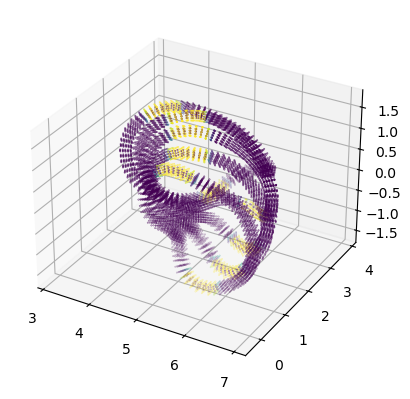

In [36]:
self = fem
import numpy as onp
from coilforce.coil_fem    import _validate_support_dofs

base_curves_dofs = init_dofs

winkler_k = float(self.problem_options['winkler_k'])
sd = _validate_support_dofs(support_dofs, n_base)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
for i, coil_mesh in enumerate(self.meshes):
    pts_i  = self._mesh_points_from_dofs(base_curves_dofs[i], i)
    pts_np = onp.asarray(pts_i, dtype=onp.float64)
    n_nodes = pts_np.shape[0]
    surf_idx = onp.asarray(self._surface_node_indices[i], dtype=onp.int32)
    weights_surf = onp.asarray(
        self._compute_support_weights(i, pts_i, base_curves_dofs[i], sd[i]),
        dtype=onp.float64,
    )
    weight_full = onp.zeros(n_nodes, dtype=onp.float64)
    weight_full[surf_idx] = weights_surf
    ax.scatter(
        pts_np[:, 0], 
        pts_np[:, 1], 
        pts_np[:, 2],
        s=0.1,
        c=weight_full
    )

## 4. Diagnostic forward solve <a id='4-run'></a>

`fem.run()` performs the full FEM pipeline and returns raw solution arrays for
inspection.  **Do not use this for gradient computation** — use
`fem.objective()` instead (Section 5).

In [37]:
t0 = time.perf_counter()
result = fem.run()
dt = time.perf_counter() - t0
print(f"Forward solve finished in {dt:.1f} s")

# result keys: 'displacements', 'von_mises', 'mesh_points'
for i, vm in enumerate(result['von_mises']):
    print(
        f"  coil {i}: max Von Mises = {float(jnp.max(vm))/1e6:.1f} MPa  "
        f"  mean = {float(jnp.mean(vm))/1e6:.1f} MPa"
    )

Forward solve finished in 8.5 s
  coil 0: max Von Mises = 1367.0 MPa    mean = 256.0 MPa
  coil 1: max Von Mises = 1250.4 MPa    mean = 292.2 MPa
  coil 2: max Von Mises = 1313.9 MPa    mean = 287.2 MPa
  coil 3: max Von Mises = 1148.8 MPa    mean = 232.4 MPa
  coil 4: max Von Mises = 1006.5 MPa    mean = 174.2 MPa


### 4a. Export to VTU for ParaView

In [38]:
import meshio

for i, (mesh, pts, vm, sol) in enumerate(
    zip(fem.meshes, result['mesh_points'], result['von_mises'], result['displacements'])
):
    # Cell-average Von Mises (one value per cell for colouring)
    vm_cell_avg = np.asarray(jnp.mean(vm, axis=-1))  # (n_cells,)

    # Node displacements
    disp = np.asarray(sol)   # (n_nodes, 3)

    meshio.Mesh(
        points=np.asarray(pts),
        cells=[(mesh.meshio_cell_type, np.asarray(mesh.cells))],
        cell_data={'von_mises_MPa': [vm_cell_avg / 1e6]},
        point_data={'displacement_m': disp},
    ).write(f"coil_{i}_initial.vtu")
    print(f"Wrote coil_{i}_initial.vtu")

Wrote coil_0_initial.vtu
Wrote coil_1_initial.vtu
Wrote coil_2_initial.vtu
Wrote coil_3_initial.vtu
Wrote coil_4_initial.vtu


## 5. Verify gradients with a finite-difference check <a id='5-grad-check'></a>

Before running optimisation it is good practice to confirm that `jax.grad`
matches a finite-difference estimate on a few DOFs.

In [39]:
# Objective: softmax Von Mises over all base coils.
# fem.objective() returns a dict {metric_name: scalar}; callers combine entries.
# beta controls sharpness; beta→∞ recovers the true max.
BETA = 3000.0    # smoothness; tune to problem scale

def J(base_curves_dofs, base_currents_dofs, support_dofs=None):
    """Scalar softmax Von Mises objective, summed over all base coils."""
    objs = fem.objective(
        base_curves_dofs,
        base_currents_dofs,
        support_dofs,
        metrics = ('soft_max_von_mises',),
    )
    return objs['soft_max_von_mises']

In [41]:
# Test for gradient calculation that overflows a 4060
# Gradient w.r.t. (base_curves_dofs, base_currents_dofs) simultaneously.
# Add argnums=2 if support_dofs are being optimised.
grad_J = jax.grad(J, argnums=(0, 1))

# --- evaluate once to JIT-compile ---
g_dofs, g_curr = grad_J(init_dofs, init_currents)
print("Gradient computed. Shapes:")
for i, gd in enumerate(g_dofs):
    print(f"  coil {i} DOF grad shape: {gd.shape}")
print(f"  current grad shape: {g_curr.shape}")
# ---- Finite-difference check on one DOF of coil 0 ----
h = 1e-5    # step size
dof_idx = 3  # which DOF to perturb

def J_coil0_dof(eps):
    perturbed = init_dofs[0].at[dof_idx].add(eps)
    dofs_p = [perturbed] + init_dofs[1:]
    return J(dofs_p, init_currents)   # support_dofs=None (static)

J_fwd = float(J_coil0_dof(+h))
J_bwd = float(J_coil0_dof(-h))
fd_grad = (J_fwd - J_bwd) / (2 * h)
ad_grad = float(g_dofs[0][dof_idx])

print(f"J: {J_fwd:.6e}")
print(f"FD  gradient: {fd_grad:.6e}")
print(f"AD  gradient: {ad_grad:.6e}")
print(f"Relative err: {abs(fd_grad - ad_grad) / (abs(ad_grad) + 1e-30):.2e}")

Gradient computed. Shapes:
  coil 0 DOF grad shape: (123,)
  coil 1 DOF grad shape: (123,)
  coil 2 DOF grad shape: (123,)
  coil 3 DOF grad shape: (123,)
  coil 4 DOF grad shape: (123,)
  current grad shape: (5,)
J: 6.086592e+09
FD  gradient: -2.183542e+09
AD  gradient: -2.183542e+09
Relative err: 2.71e-08


## 6. JAX-native L-BFGS-B optimisation <a id='6-jax-optim'></a>

`jax.scipy.optimize.minimize` wraps the same L-BFGS-B algorithm as scipy but
runs entirely inside JAX (including the line search), so the optimiser loop
itself can be JIT-compiled.

We flatten `(dofs_list, currents)` into a single 1-D array for the solver,
then reshape inside the objective.

In [42]:
# ---- Flatten / unflatten utilities ----

def pack_x(dofs: list[jax.Array], currents: jax.Array) -> jax.Array:
    """Concatenate all DOFs + currents into a single 1-D JAX array."""
    return jnp.concatenate([d.ravel() for d in dofs] + [currents.ravel()])

def unpack_x(x: jax.Array) -> tuple[list[jax.Array], jax.Array]:
    """Inverse of pack_x.  Uses the stored dof_sizes from Section 2."""
    pos = 0
    dofs = []
    for sz in dof_sizes:
        dofs.append(x[pos : pos + sz])
        pos += sz
    currents = x[pos : pos + n_base]
    return dofs, currents

x0 = pack_x(init_dofs, init_currents)
print("Packed x0 length:", x0.shape[0])

# Quick round-trip check
dofs_rt, currents_rt = unpack_x(x0)
assert all(jnp.allclose(a, b) for a, b in zip(dofs_rt, init_dofs))
assert jnp.allclose(currents_rt, init_currents)
print("Pack/unpack round-trip: OK")

Packed x0 length: 620
Pack/unpack round-trip: OK


In [ ]:
# ---- Objective in flat-array form for jax.scipy.optimize ----

def J_flat_jax(x: jax.Array) -> jax.Array:
    dofs, currents = unpack_x(x)
    return J(dofs, currents)

# jax_fem's Newton solver uses numpy internally (onp.vstack, np.linalg.norm),
# so the forward pass cannot be JIT-traced: abstract inputs would hit
# TracerArrayConversionError inside split_and_compute_cell.  Run eagerly:
# jax.grad uses the registered @custom_vjp adjoint without re-tracing the
# primal Newton solver body.
J_and_dJ_jax = jax.value_and_grad(J_flat_jax)

In [18]:
# ---- Optional: lower/upper bounds ----
# Keep currents positive and within ±20% of initial value.
# DOFs are unconstrained.

n_dofs_total = sum(dof_sizes)

lb = np.full(n_dofs_total + n_base, -np.inf)
ub = np.full(n_dofs_total + n_base,  np.inf)

I0_np = np.asarray(init_currents)
lb[n_dofs_total:] = I0_np * 0.8
ub[n_dofs_total:] = I0_np * 1.2

bounds_jax = list(zip(lb, ub))

## 7. Scipy L-BFGS-B with simsopt objectives <a id='7-scipy-optim'></a>

Using `scipy.optimize.minimize` with `jac=True` lets you:

* Mix JAX-computed FEM gradients with simsopt's Python/C++ gradients
  (e.g. quasisymmetry residual, coil length, coil-coil distance).
* Use scipy's richer convergence callbacks and bound handling.
* Plug in other simsopt `LeastSquaresProblem` objectives without rewriting them.

The pattern is:

```
x_flat  →  unpack  →  dofs_list, currents
                           │
              ┌────────────┴──────────────┐
              ▼                           ▼
     JAX FEM objective          simsopt objective
     (jax.value_and_grad)       (update simsopt curves → Jf.J(), Jf.dJ())
              │                           │
              └────────────┬──────────────┘
                           ▼
                  val_total, grad_total  →  (float, np.ndarray)
```

In [18]:
from scipy.optimize import minimize
from simsopt.objectives import SquaredFlux
from simsopt.objectives.utilities import QuadraticPenalty
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
)
from simsopt.field.force import LpCurveForce
from simsopt.field.coil import RegularizedCoil
from simsopt.field.selffield import regularization_rect
from simsopt import load, save
from simsopt.mhd import Vmec
from simsopt.mhd.virtual_casing import VirtualCasing

In [33]:
# ---- Virtual casing resolution ----
n_phi = 25        # half fp like in virtual casing convention
n_theta = 50
vc_src_nphi = 40  # half fp like in virtual casing convention
vc_src_ntheta = 80

def load_eq(file_name):
    eq = Vmec(file_name, keep_all_files=True)
    vc = VirtualCasing.from_vmec(
        file_name,
        src_nphi=vc_src_nphi,
        src_ntheta=vc_src_ntheta,
        trgt_nphi=n_phi,
        trgt_ntheta=n_theta,
    )
    Bnormal_plasma = vc.B_external_normal
    plasma_surface_vc = type(eq.boundary)(
        nfp=eq.boundary.nfp,
        stellsym=eq.boundary.stellsym,
        mpol=eq.boundary.mpol, ntor=eq.boundary.ntor,
        quadpoints_phi=np.linspace(0, 1/2/eq.boundary.nfp, n_phi, endpoint=False),
        quadpoints_theta=np.linspace(0, 1, n_theta, endpoint=False),
    )
    plasma_surface_vc.set_dofs(eq.boundary.get_dofs())
    return eq, Bnormal_plasma, plasma_surface_vc, vc


In [38]:
eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')

In [40]:
base_curves_jax

In [39]:
# def run_filament_free(base_curves_jax, base_currents_jax, plasma_surface, winding_surface, Bnormal_plasma, MAXITER, force_mode):
force_mode = True
plasma_surface = plasma_surface_vc


# --------------------------------------
coils = coils_via_symmetries(base_curves_jax, base_currents_jax, plasma_surface.nfp, True)

curves_for_ccd = [c.curve for c in coils]

bs = BiotSavart(coils)
print('Btarget should have shape', plasma_surface.normal().shape[:2])
print('Btarget has shape', Bnormal_plasma.shape)
bs.set_points(plasma_surface.gamma().reshape((-1, 3)))
Jf_norm = SquaredFlux(
    plasma_surface,
    bs,
    target=Bnormal_plasma,
    definition='normalized',
)
Jf_actual = SquaredFlux(
    plasma_surface,
    bs,
    target=Bnormal_plasma,
    definition='quadratic flux',
)
Jf_norm_cons = QuadraticPenalty(Jf_norm, FLUX_NORM_TARGET, 'max')
Jls = [
    QuadraticPenalty(
        CurveLength(c),
        LENGTH_TARGET,
        "max",
    ) for c in base_curves_jax
]
if force_mode:
    regularized_coils = [RegularizedCoil(
        c.curve, c.current, regularization_rect(0.54, 0.54)
    ) for c in coils]
    Jforce = LpCurveForce(
        target_coils=regularized_coils[:coil_per_half_fp],
        source_coils_coarse=regularized_coils,
    )
    print('Optimizing L2 force')
else:
    print('Optimizing max Von Mises')
Jccdist_actual = CurveCurveDistance(curves_for_ccd, CC_TARGET)
Jccdist = Jccdist_actual * (1 / CC_TARGET)
print('Begin ----------')
plasma_surface_cs = SurfaceRZFourier(
    nfp=plasma_surface.nfp,
    stellsym=plasma_surface.stellsym,
    mpol=plasma_surface.mpol,
    ntor=plasma_surface.ntor,
    quadpoints_phi=np.arange(64)/64,
    quadpoints_theta=np.arange(64)/64,
)
plasma_surface_cs.set_dofs(plasma_surface.get_dofs())
Jcsdist_actual = CurveSurfaceDistance(base_curves_jax, plasma_surface_cs, CP_TARGET)
Jcsdist = Jcsdist_actual * (1 / winding_surface.minor_radius())
linkNum = LinkingNumber(curves_for_ccd)
Jcs = [
    LpCurveCurvature(
        c, Lp, threshold=CURVATURE_TARGET
    )*(winding_surface.minor_radius()**Lp) for c in base_curves_jax
]
JF = (
    FLUX_WEIGHT ** 2 * Jf_norm_cons
    + CC_WEIGHT * Jccdist
    + CS_WEIGHT * Jcsdist
    + CURVATURE_WEIGHT * sum(Jcs)
    + FORCE_WEIGHT * Jforce
    + LENGTH_WEIGHT * sum(Jls)
    + LINK_WEIGHT * linkNum
)

def fun(dofs):
    JF.x = dofs
    J = JF.J()
    grad = JF.dJ()
    return J, grad

dofs = JF.x

print('MAXITER =', MAXITER)
time_filament_1 = time.time()
res = minimize(
    fun, dofs, jac=True, method='L-BFGS-B',
    options={
        'maxiter': MAXITER,
        'maxcor': 300,
        'maxfun': MAXFUN,
        'maxls': 60,
    },
    tol=1e-10,
)
time_filament_2 = time.time()
filament_time = time_filament_2 - time_filament_1
print('Filament time', filament_time)
print('Normalized flux', Jf_norm.J())
print('L2 force', Jforce.J())
print('Lengths', [j.J() for j in Jls])
print('Max curvatures', [jnp.max(jnp.abs(c.kappa())) for c in base_curves_jax])
print('Final value of terms')
print('FLUX_WEIGHT**2 * Jf_norm_cons            ', FLUX_WEIGHT**2 * Jf_norm_cons.J())
print('+ CC_WEIGHT * Jccdist                    ', CC_WEIGHT * Jccdist.J())
print('+ CS_WEIGHT * Jcsdist                    ', CS_WEIGHT * Jcsdist.J())
if force_mode:
    print('+ FORCE_WEIGHT * Jforce  ', FORCE_WEIGHT * Jforce.J())
else:
    print*('+ STRESS_WEIGHT * Jstress  ', STRESS_WEIGHT * Jstress.J())
print('+ CURVATURE_WEIGHT * sum(Jcs)', CURVATURE_WEIGHT * sum(Jcs).J())
print('+ LINK_WEIGHT * linkNum', LINK_WEIGHT * linkNum.J())
print('LENGTH_WEIGHT * QuadraticPenalty(sum(Jls))', LENGTH_WEIGHT * QuadraticPenalty(
    sum(Jls),
    LENGTH_TARGET * len(base_curves_jax),
    "max",
).J())
# return (
#     coils,
#     curves_for_ccd,
#     res,
#     filament_time,
#     Jf_norm,
#     Jf_actual,
#     Jccdist,
#     Jccdist_actual,
#     Jcsdist,
#     Jcsdist_actual,
#     Jforce,
#     Jls,
#     linkNum,
# )

AttributeError: 'CurveXYZFourierJAX' object has no attribute '_add_child'

In [ ]:

def fun(dofs):
    JF.x = dofs
    J = JF.J()
    grad = JF.dJ()
    return J, grad

dofs = JF.x

print('MAXITER =', MAXITER)
time_filament_1 = time.time()
res = minimize(
    fun, dofs, jac=True, method='L-BFGS-B',
    options={
        'maxiter': MAXITER,
        'maxcor': 300,
        'maxfun': MAXFUN,
        'maxls': 60,
    },
    tol=1e-10,
)

In [19]:
# ---- 7a. Simsopt setup (fill in your simsopt objectives) ----
#
# Example: QuadfluxPenalty on a target surface.  Replace or extend as needed.
#
from simsopt.objectives import SquaredFlux
from simsopt.field      import BiotSavart
from simsopt.field.coil import coils_via_symmetries
#
# base_curves_sim  = [...]  # simsopt CurveXYZFourier objects matching base_curves_jax
# base_currents_sim = [...]  # simsopt Current objects matching base_currents_jax
# target_surface   = ...    # simsopt SurfaceRZFourier or similar
#
coils_sim = coils_via_symmetries(base_curves_sim, base_currents_sim, nfp, stellsym)
bs        = BiotSavart(coils_sim)
Jf        = SquaredFlux(target_surface, bs)
#
# USER: assign the simsopt objects above and set HAS_SIMSOPT_OBJ = True
# -------------------------------------------------------------------------

HAS_SIMSOPT_OBJ = False   # set to True once you have filled in the above
W_FEM    = 1.0            # weight on FEM objective
W_SIM    = 1e-2           # weight on simsopt objective (tune to balance scales)

In [20]:
# ---- 7b. JAX-side: JIT-compiled value_and_grad in flat-array form ----

# Reuse J_and_dJ_jax defined in Section 6.
# (Already JIT-compiled after first call in Section 6.)


# ---- 7c. Simsopt gradient helper ----

def simsopt_J_and_dJ(dofs_list: list[jax.Array]) -> tuple[float, np.ndarray]:
    """
    Evaluate simsopt objectives and return (value, gradient_flat).

    gradient_flat has shape (n_dofs_total,) -- one entry per DOF across
    all base coils, concatenated in the same order as pack_x.
    Currents are assumed fixed for the simsopt objectives; extend if needed.
    """
    if not HAS_SIMSOPT_OBJ:
        return 0.0, np.zeros(sum(dof_sizes))

    # Sync simsopt curve objects with current JAX DOFs
    for c_sim, d_jax in zip(base_curves_sim, dofs_list):
        c_sim.x = np.asarray(d_jax)   # simsopt uses .x attribute

    val  = float(Jf.J())
    # Jf.dJ() returns gradient w.r.t. all free DOFs of Jf's dependency graph.
    # simsopt orders them the same as the flattened DOFs list if the curve
    # objects are the *only* free DOFs.
    grad = np.asarray(Jf.dJ())        # shape (n_dofs_total,)
    return val, grad


# ---- 7d. Combined objective for scipy ----

history_scipy = []

def combined_J_and_dJ(x_flat_np: np.ndarray) -> tuple[float, np.ndarray]:
    """
    Callable for scipy.optimize.minimize(jac=True).

    Returns (scalar, 1-D ndarray).
    """
    x_jax = jnp.asarray(x_flat_np)

    # --- JAX FEM objective + gradient ---
    fem_val, fem_grad = J_and_dJ_jax(x_jax)
    fem_val  = float(fem_val)
    fem_grad = np.asarray(fem_grad)   # (n_dofs_total + n_base,)

    # --- simsopt objective + gradient (DOFs only, no current gradient here) ---
    dofs_list, _ = unpack_x(x_jax)
    sim_val, sim_grad_dofs = simsopt_J_and_dJ(dofs_list)

    # Pad simsopt gradient with zeros for the current entries
    sim_grad_full = np.concatenate([sim_grad_dofs, np.zeros(n_base)])

    val  = W_FEM * fem_val  + W_SIM * sim_val
    grad = W_FEM * fem_grad + W_SIM * sim_grad_full

    history_scipy.append((val, float(np.linalg.norm(grad))))
    it = len(history_scipy)
    if it % 5 == 0:
        print(f"  iter {it:4d}  J = {val:.6e}  |g| = {np.linalg.norm(grad):.3e}")

    return val, grad

In [21]:
# ---- 7e. Bounds ----
# Same bounds as in Section 6; scipy accepts them directly.
scipy_bounds = scipy.optimize.Bounds(lb=lb, ub=ub)

# ---- 7f. Run scipy L-BFGS-B ----
print("Starting scipy L-BFGS-B optimisation …")
t0 = time.perf_counter()

result_scipy = scipy.optimize.minimize(
    combined_J_and_dJ,
    np.asarray(x0),            # scipy needs a numpy array
    method  = 'L-BFGS-B',
    jac     = True,            # function returns (val, grad) tuple
    bounds  = scipy_bounds,
    options = dict(
        maxiter = 20,
        ftol    = 1e-12,       # relative function tolerance
        gtol    = 1e-7,        # gradient infinity-norm tolerance
        maxls   = 20,          # max line-search steps
        iprint  = -1,          # suppress internal fortran output
    ),
)

dt_scipy = time.perf_counter() - t0
print(f"\nDone in {dt_scipy:.1f} s")
print(f"  Converged : {result_scipy.success}")
print(f"  Message   : {result_scipy.message}")
print(f"  Iterations: {result_scipy.nit}")
print(f"  Fun evals : {result_scipy.nfev}")
print(f"  Final J   : {result_scipy.fun:.6e}")

Starting scipy L-BFGS-B optimisation …


/tmp/ipykernel_1478777/1978198686.py:9: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result_scipy = scipy.optimize.minimize(


  iter    5  J = 3.840416e+09  |g| = 2.055e+11
  iter   10  J = 3.775246e+09  |g| = 2.085e+11
  iter   15  J = 3.753957e+09  |g| = 2.029e+11
  iter   20  J = 3.731676e+09  |g| = 1.846e+11
  iter   25  J = 3.711985e+09  |g| = 1.828e+11

Done in 168.6 s
  Converged : False
  Message   : STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  Iterations: 20
  Fun evals : 29
  Final J   : 3.688777e+09


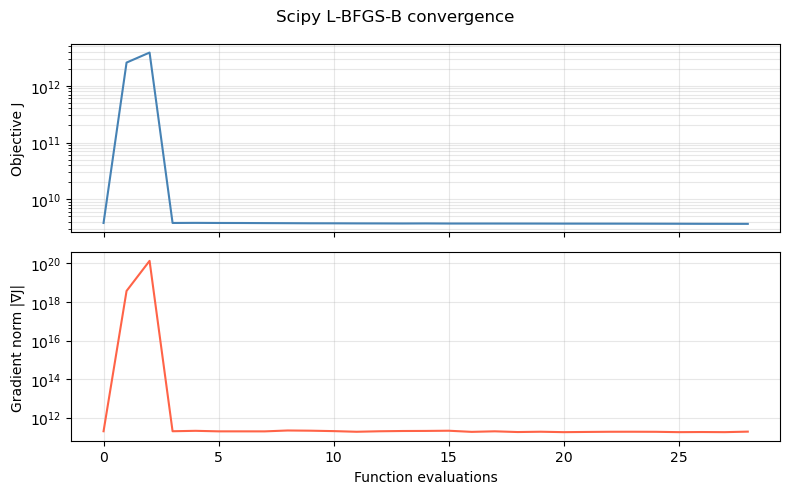

In [22]:
# ---- 7g. Convergence plot ----
if history_scipy:
    vals, gnorms = zip(*history_scipy)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    ax1.semilogy(vals,   color='steelblue', lw=1.5)
    ax1.set_ylabel('Objective J')
    ax1.grid(True, which='both', alpha=0.3)

    ax2.semilogy(gnorms, color='tomato', lw=1.5)
    ax2.set_ylabel('Gradient norm |∇J|')
    ax2.set_xlabel('Function evaluations')
    ax2.grid(True, which='both', alpha=0.3)

    plt.suptitle('Scipy L-BFGS-B convergence')
    plt.tight_layout()
    plt.savefig('convergence.png', dpi=150)
    plt.show()

In [23]:
# Extract optimised DOFs and currents
x_opt = jnp.asarray(result_scipy.x)
dofs_opt, currents_opt = unpack_x(x_opt)

print("Current change [%]:")
print(np.asarray(100 * (currents_opt - init_currents) / jnp.abs(init_currents + 1e-30)))

Current change [%]:
[0. 0. 0. 0. 0.]


### 7h. Tip: fixing currents or DOFs during optimisation

If you want to keep currents fixed (only optimise coil shapes), simply remove
the current slice from the packed vector:

```python
def pack_dofs_only(dofs):     return np.concatenate([np.asarray(d) for d in dofs])
def unpack_dofs_only(x_flat): ...

def J_and_dJ_dofs_only(x_flat):
    dofs, _ = unpack_dofs_only(x_flat)
    val, (d_dofs, _) = jax.value_and_grad(J, argnums=(0, 1))(dofs, init_currents)
    grad = np.concatenate([np.asarray(g) for g in d_dofs])
    return float(val), grad
```

Similarly, to include **only currents** (fixing shapes), unpack just the
current slice.

## 8. Post-processing the optimised solution <a id='8-postproc'></a>

In [24]:
# Forward solve at the optimised point
result_opt = fem.run(base_curves_dofs=dofs_opt, base_currents_dofs=currents_opt)

print("\nVon Mises comparison  initial vs optimised:")
print(
    f"{'coil':>5}  \
    {'max_init [MPa]':>16}  \
    {'max_opt [MPa]':>14}  \
    {'Δ [%]':>7}"
)
for i, (vm_i, vm_o) in enumerate(zip(result['von_mises'], result_opt['von_mises'])):
    mi = float(jnp.max(vm_i)) / 1e6
    mo = float(jnp.max(vm_o)) / 1e6
    print(f"{i:>5}  {mi:>16.1f}  {mo:>14.1f}  {100*(mo-mi)/mi:>+7.1f}")


Von Mises comparison  initial vs optimised:
 coil        max_init [MPa]       max_opt [MPa]        Δ [%]
    0             868.4           829.2     -4.5
    1             880.7           838.2     -4.8
    2             865.4           829.2     -4.2
    3             725.7           709.8     -2.2
    4             485.4           482.3     -0.6


In [30]:
# Export optimised solution to VTU
for i, (mesh, pts, vm, sol) in enumerate(
    zip(fem.meshes, result_opt['mesh_points'], result_opt['von_mises'], result_opt['displacements'])
):
    vm_cell_avg = np.asarray(jnp.mean(vm, axis=-1))
    disp = np.asarray(sol)
    meshio.Mesh(
        points=np.asarray(pts),
        cells=[(mesh.meshio_cell_type, np.asarray(mesh.cells))],
        cell_data={'von_mises_MPa': [vm_cell_avg / 1e6]},
        point_data={'displacement_m': disp},
    ).write(f"coil_{i}_optimised.vtu")
    print(f"Wrote coil_{i}_optimised.vtu")

Wrote coil_0_optimised.vtu
Wrote coil_1_optimised.vtu
Wrote coil_2_optimised.vtu
Wrote coil_3_optimised.vtu
Wrote coil_4_optimised.vtu


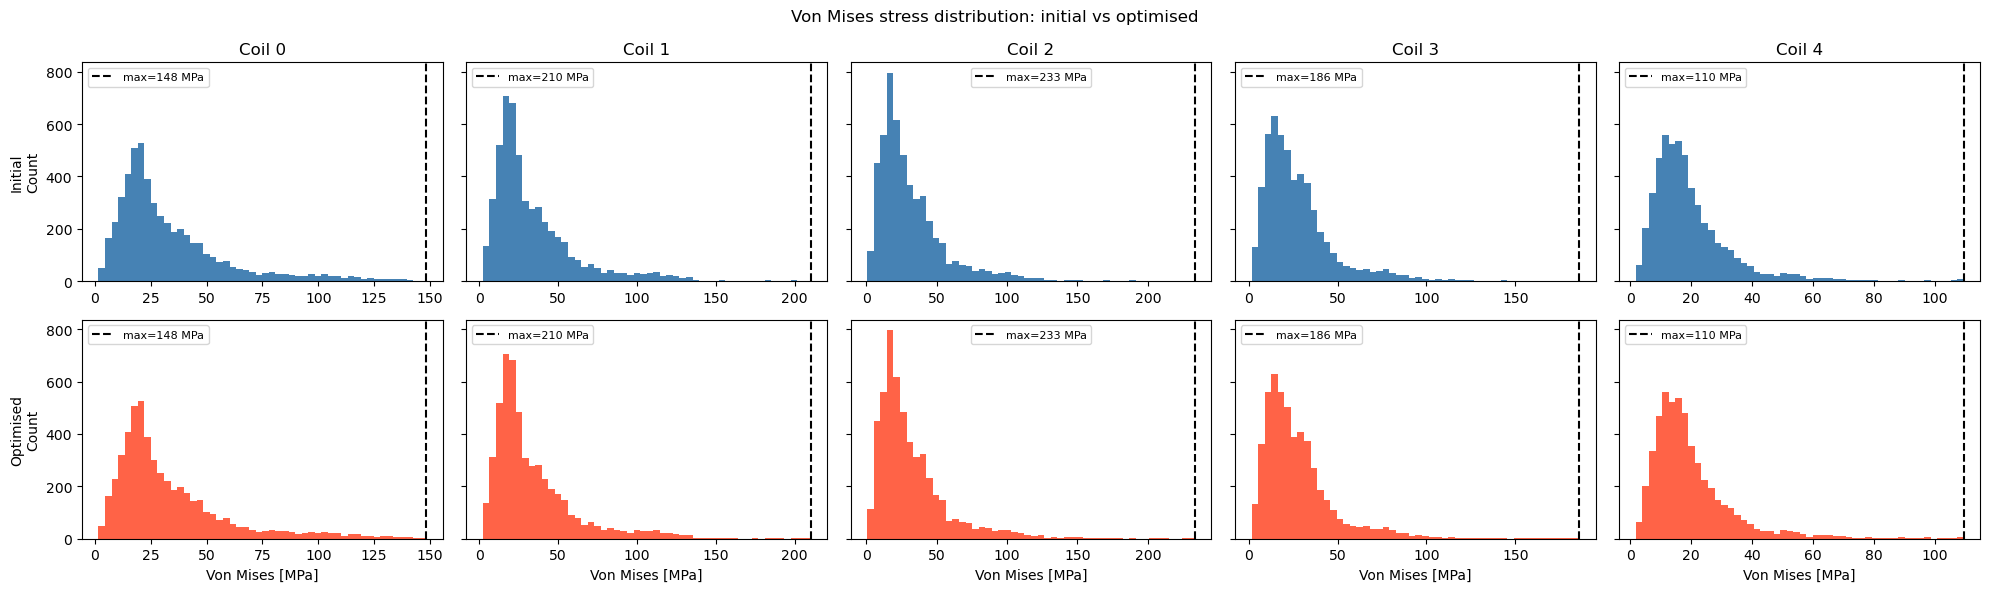

In [31]:
# Side-by-side stress histograms: initial vs optimised
fig, axes = plt.subplots(2, n_base, figsize=(4 * n_base, 6), sharey='row')
if n_base == 1:
    axes = axes.reshape(2, 1)

labels = ['Initial', 'Optimised']
results = [result, result_opt]

for row, (label, res) in enumerate(zip(labels, results)):
    for col, vm in enumerate(res['von_mises']):
        ax = axes[row, col]
        ax.hist(np.asarray(vm).ravel() / 1e6, bins=50, color='steelblue' if row == 0 else 'tomato',
                edgecolor='none')
        ax.axvline(float(jnp.max(vm)) / 1e6, color='k', lw=1.5, ls='--', label=f'max={float(jnp.max(vm))/1e6:.0f} MPa')
        ax.legend(fontsize=8)
        if row == 0:
            ax.set_title(f'Coil {col}')
        ax.set_xlabel('Von Mises [MPa]' if row == 1 else '')
    axes[row, 0].set_ylabel(f'{label}\nCount')

plt.suptitle('Von Mises stress distribution: initial vs optimised')
plt.tight_layout()
plt.savefig('von_mises_comparison.png', dpi=150)
plt.show()

## Appendix A: Optimising the support location with `support_dofs`

Instead of trying a discrete set of mounting locations (BC permutation), you
can treat the support location as a **continuous optimisable variable** by
passing `support_dofs` into the gradient-based optimiser alongside
`base_curves_dofs` and `base_currents_dofs`.

Set `support_dofs = [{'phi_mount': phi_0}]` (one dict per base coil) and
use `dofs` inside `support_fn` to parameterise the weight function.
The Winkler stiffness is fully differentiable through `support_dofs`, so
`jax.grad(J, argnums=(0, 1, 2))` gives the correct adjoint gradient.

In [ ]:
# Example: optimise support location jointly with coil geometry.
# Each coil gets one scalar parameter phi_mount (toroidal angle of the clamp).
# The support_fn uses a sigmoid to produce smooth, differentiable weights.

def support_fn_with_phi(surface_points, coil, dofs):
    """Soft-sphere support centred at the centreline point nearest to phi_mount."""
    phi_mount = dofs['phi_mount']  # scalar, optimisable
    gamma = coil.gamma()           # (n_quad, 3)
    phi_gamma = jnp.arctan2(gamma[:, 1], gamma[:, 0])   # (n_quad,)
    dphi = jnp.abs(phi_gamma - phi_mount)
    dphi = jnp.minimum(dphi, 2 * jnp.pi - dphi)        # wrap to [-pi, pi]
    nearest_idx = jnp.argmin(dphi)
    mount_pt = gamma[nearest_idx]                        # (3,)
    d = jnp.sqrt(jnp.sum((surface_points - mount_pt)**2, axis=-1) + 1e-30)
    return jax.nn.sigmoid(sigmoid_beta * (clamp_radius - d))

# Initial mount angle per base coil (can be made into an optimisable vector)
phi_mount_init = float(jnp.mean(jnp.arctan2(base_curves_jax[0].gamma()[:, 1],
                                             base_curves_jax[0].gamma()[:, 0])))
init_support_dofs = [{'phi_mount': jnp.asarray(phi_mount_init)}] * n_base

fem_phi = CoilFEM(
    base_curves_jax     = base_curves_jax,
    base_currents_jax   = base_currents_jax,
    nfp             = nfp,
    stellsym        = stellsym,
    mesh_options    = mesh_options,
    material_options = material_options,
    support_fn      = support_fn_with_phi,
    support_dofs    = init_support_dofs,
    problem_options = problem_options,
)

def J_phi(base_curves_dofs, base_currents_dofs, sup_dofs):
    objs = fem_phi.objective(
        base_curves_dofs, base_currents_dofs, sup_dofs,
        metrics=('soft_max_von_mises',),
    )
    return objs['soft_max_von_mises']

# Gradients w.r.t. coil DOFs, currents, AND support location simultaneously
grad_phi = jax.grad(J_phi, argnums=(0, 1, 2))
g_d, g_c, g_s = grad_phi(init_dofs, init_currents, init_support_dofs)
print("Support-location gradient (phi_mount coil 0):", float(g_s[0]['phi_mount']))

## Appendix B: Choosing the softmax temperature β

The softmax objective $\frac{1}{\beta} \log \sum e^{\beta \sigma_{\text{vm}}}$
approximates the max stress with a smooth surrogate:

* **Small β** → smooth, easy to optimise, but underestimates the peak.
* **Large β** → tracks the true max closely, but gradients concentrate on a
  single element and become hard to use.

A common strategy is a **continuation scheme**: start with small β, optimise,
then increase β and warm-start from the previous result.

In [ ]:
# Continuation over β: small → large
BETA_SCHEDULE = [5.0, 15.0, 30.0, 60.0]

x_cont = np.asarray(x0)   # warm-start from initial point
 
for beta_val in BETA_SCHEDULE:
    print(f"\n--- β = {beta_val} ---")

    def J_beta(dofs, currents):
        return fem.objective(
            dofs, currents,
            metrics=('soft_max_von_mises',),
        )

    J_and_dJ_beta = jax.jit(jax.value_and_grad(
        lambda x: J_beta(*unpack_x(x))
    ))

    def fun_beta(x_np):
        v, g = J_and_dJ_beta(jnp.asarray(x_np))
        return float(v), np.asarray(g)

    res = scipy.optimize.minimize(
        fun_beta, x_cont,
        method='L-BFGS-B', jac=True,
        bounds=scipy_bounds,
        options=dict(maxiter=50, ftol=1e-10, gtol=1e-6, iprint=-1),
    )
    x_cont = res.x
    print(f"  J = {res.fun:.6e}  converged={res.success}  nit={res.nit}")

dofs_cont, currents_cont = unpack_x(jnp.asarray(x_cont))
print("\nContinuation optimisation complete.")